<h3 align="center"> ROC AUC Curve: Cost Benefit Analysis</h3>

We will generate synthetic dataset using make_classification method

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [6]:
X , y = make_classification(
    n_features=10, 
    n_samples=1000, 
    n_informative=4,
    n_redundant=6,
    n_repeated=0,
    n_classes=2, 
    random_state=42
) 
x_train , x_test , y_train , y_test = train_test_split(X , y , test_size=0.25 )


### Train model using logistic regression 

In [8]:
model = LogisticRegression()
model.fit(x_train , y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [13]:
from sklearn.metrics import classification_report
y_pred = model.predict(x_test)
report = classification_report(y_test , y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.74      0.70      0.72       132
           1       0.69      0.73      0.71       118

    accuracy                           0.72       250
   macro avg       0.72      0.72      0.72       250
weighted avg       0.72      0.72      0.72       250



Let's assume above is the classification model for pneumonia detection. In this case, a recall of 0.66 for positive class is pretty bad because out of 100 psenumonia patients you are detecting the disease only in 66 and to remaining 34 patients you are saying you don't have a disease. We would like to increase this number even though it comes at the cost of increased false positives (i.e. telling a person that you have pneumonia, when in reality they don't).

Reduce the probability threshold to 0.4 (from a default of 0.5) to capture more cases of pneumonia

In [21]:
probabilities = model.predict_proba(x_test)[:,1]
y_pred = (probabilities > 0.4).astype(int)

report = classification_report(y_test , y_pred)
print(report)



              precision    recall  f1-score   support

           0       0.74      0.49      0.59       132
           1       0.59      0.81      0.68       118

    accuracy                           0.64       250
   macro avg       0.66      0.65      0.63       250
weighted avg       0.67      0.64      0.63       250



As you can see here for class 1, the recall increased to 82%. Which is good but now by business manager is saying they need 90% recall. We will find probability thresold associated with 90% recall using ROC curve.

### Calculate FPR, TPR

In [25]:
from sklearn.metrics import roc_curve
fpr , tpr , threshold = roc_curve(y_test , probabilities)
fpr[:5], tpr[:5], threshold[:5]

(array([0.        , 0.        , 0.        , 0.02272727, 0.02272727]),
 array([0.        , 0.00847458, 0.19491525, 0.19491525, 0.20338983]),
 array([       inf, 0.96818129, 0.87487892, 0.85456729, 0.85193734]))

In [30]:
desired_recall = 0.9 
closet_index = np.argmin(abs(tpr-desired_recall))
tpr[closet_index] , fpr[closet_index] , threshold[closet_index]


(np.float64(0.8983050847457628),
 np.float64(0.6666666666666666),
 np.float64(0.33225211379170777))

What this is saying is you need to configure your probability threshold to be 0.26 for a desired_recall value. Also you will have 0.7 false positive rate which is pretty high. Do not worry because later we will try a better model (XGBoost)

In [33]:
from sklearn.metrics import auc
area = auc(fpr , tpr)
area

0.7697098099640473

### Plot ROC Curve

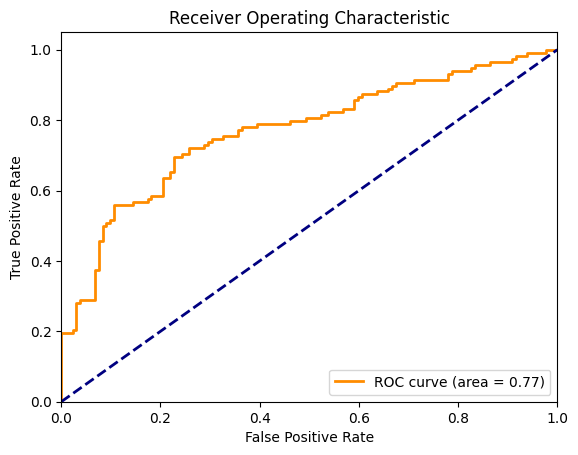

In [34]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % area)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### Now Train XGBoost Model

In [37]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

model = XGBClassifier()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.92      0.95       132
           1       0.92      0.97      0.94       118

    accuracy                           0.94       250
   macro avg       0.94      0.95      0.94       250
weighted avg       0.95      0.94      0.94       250



In [48]:
probabilities_xgb = model.predict_proba(x_test)[:,1]
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, probabilities_xgb)

fpr_xgb[:5], tpr_xgb[:5], thresholds_xgb[:5]

(array([0.        , 0.        , 0.        , 0.00757576, 0.00757576]),
 array([0.        , 0.00847458, 0.04237288, 0.04237288, 0.6440678 ]),
 array([       inf, 0.99994934, 0.9999162 , 0.9999112 , 0.99403584],
       dtype=float32))

In [49]:
area2 = auc(fpr_xgb, tpr_xgb)
area2

0.967835130970724

### Plot ROC Curve for Logistic Regression and XGBoost Side by Side

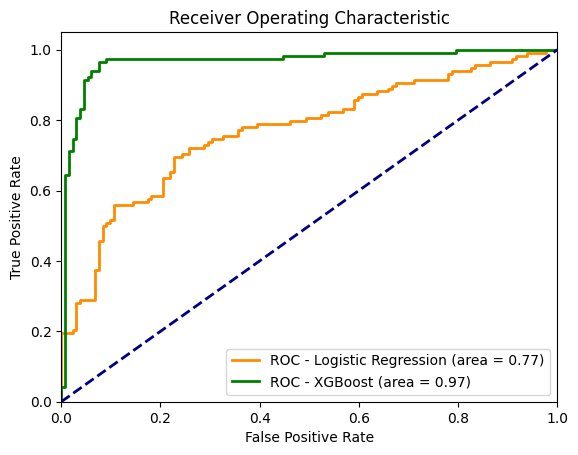

In [50]:
plt.figure()

plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC - Logistic Regression (area = %0.2f)' % area)
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label='ROC - XGBoost (area = %0.2f)' % area2)

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()